In [8]:
from google.colab import files
import zipfile
import pandas as pd
import io

# Upload ZIP file
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

# Extract and read CSV
with zipfile.ZipFile(io.BytesIO(uploaded[zip_name]), "r") as zip_ref:
    csv_name = [name for name in zip_ref.namelist()
                if name.lower().endswith(".csv")][0]

    with zip_ref.open(csv_name) as csv_file:
        df = pd.read_csv(csv_file, encoding="latin1")

print("✅ CSV loaded successfully!")
print("File:", csv_name)
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Saving archive (2).zip to archive (2) (3).zip
✅ CSV loaded successfully!
File: car data.csv
Shape: (301, 9)

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
# Check the dataset
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission   

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Car Age column created successfully!

Dataset Shape: (299, 10)

Statistical Summary:


,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478,4.384615
std,2.896868,4.984240,8.566332,39015.170352,0.248720,2.896868
min,2003.000000,0.100000,0.320000,500.000000,0.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000,2.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000,4.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000,6.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,15.000000


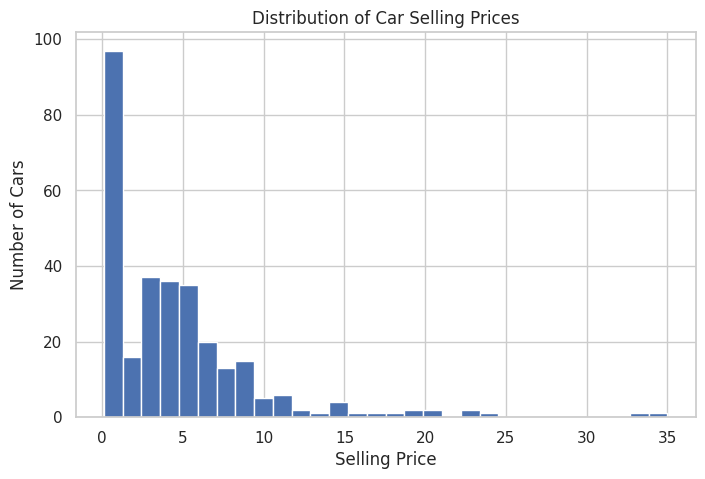

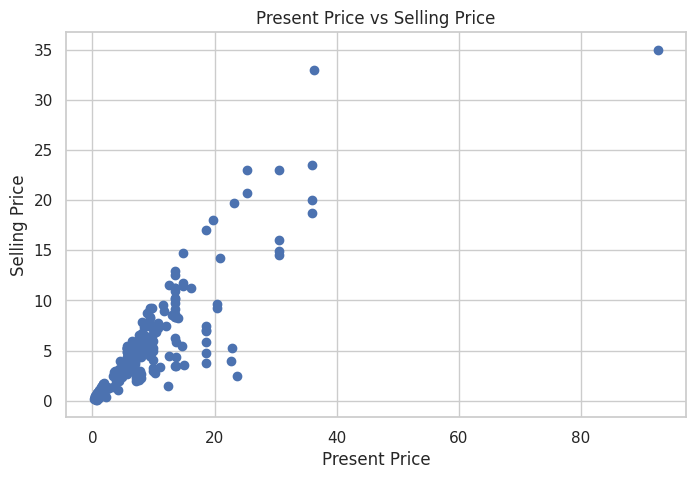

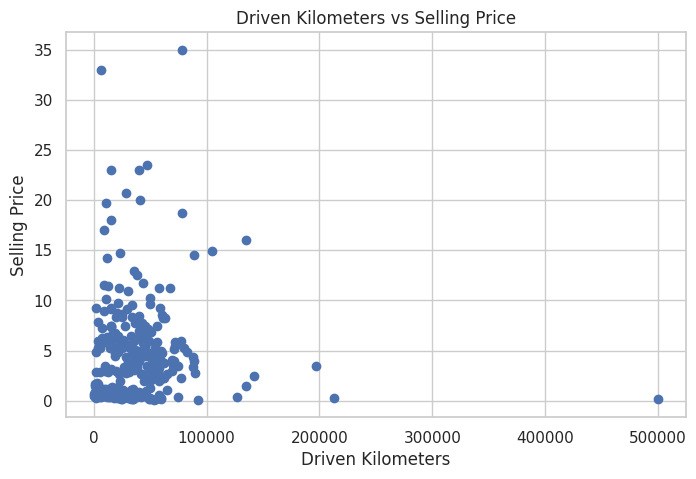

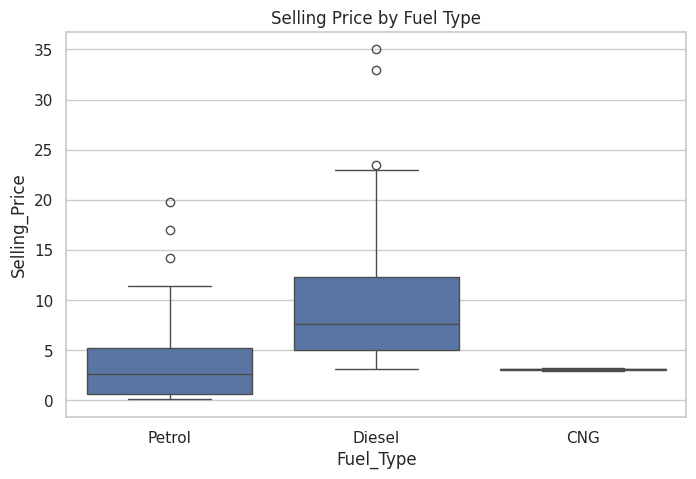

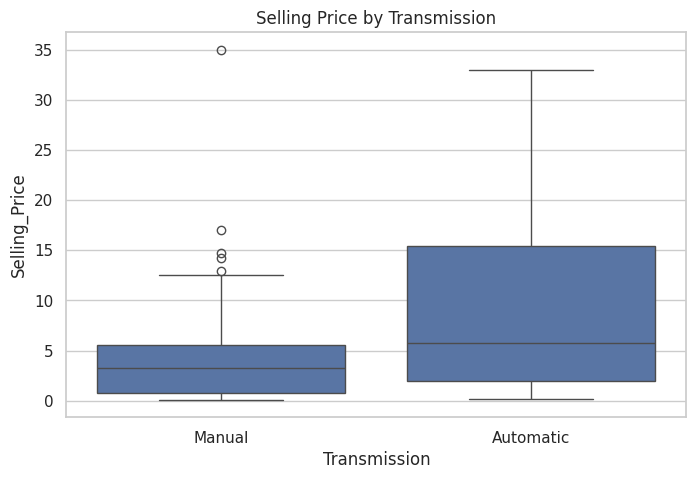


✅ Data preprocessing and EDA completed!


In [10]:
# ==============================
# CODEALPHA TASK 3
# CAR PRICE PREDICTION
# DATA PREPROCESSING & EDA
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy of the dataset
data = df.copy()

# ------------------------------
# 1. Data Cleaning
# ------------------------------

# Remove duplicate rows
data = data.drop_duplicates()

# Check missing values
print("Missing Values:")
print(data.isnull().sum())

# ------------------------------
# 2. Feature Engineering
# ------------------------------

# Calculate car age
current_year = data["Year"].max()
data["Car_Age"] = current_year - data["Year"]

print("\nCar Age column created successfully!")

# ------------------------------
# 3. Basic Statistics
# ------------------------------

print("\nDataset Shape:", data.shape)

print("\nStatistical Summary:")
display(data.describe())

# ------------------------------
# 4. Selling Price Distribution
# ------------------------------

plt.figure(figsize=(8, 5))
plt.hist(data["Selling_Price"], bins=30)
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Selling Prices")
plt.show()

# ------------------------------
# 5. Present Price vs Selling Price
# ------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(data["Present_Price"], data["Selling_Price"])
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")
plt.show()

# ------------------------------
# 6. Driven Kilometers vs Selling Price
# ------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(data["Driven_kms"], data["Selling_Price"])
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")
plt.title("Driven Kilometers vs Selling Price")
plt.show()

# ------------------------------
# 7. Fuel Type vs Selling Price
# ------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=data)
plt.title("Selling Price by Fuel Type")
plt.show()

# ------------------------------
# 8. Transmission vs Selling Price
# ------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(x="Transmission", y="Selling_Price", data=data)
plt.title("Selling Price by Transmission")
plt.show()

print("\n✅ Data preprocessing and EDA completed!")

Training rows: 239
Testing rows: 60

Linear Regression
MAE : 1.473
RMSE: 2.525
R²  : 0.753

Random Forest Regression
MAE : 1.551
RMSE: 3.756
R²  : 0.453

Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472546,2.524505,0.752723
1,Random Forest Regression,1.550961,3.755667,0.452726


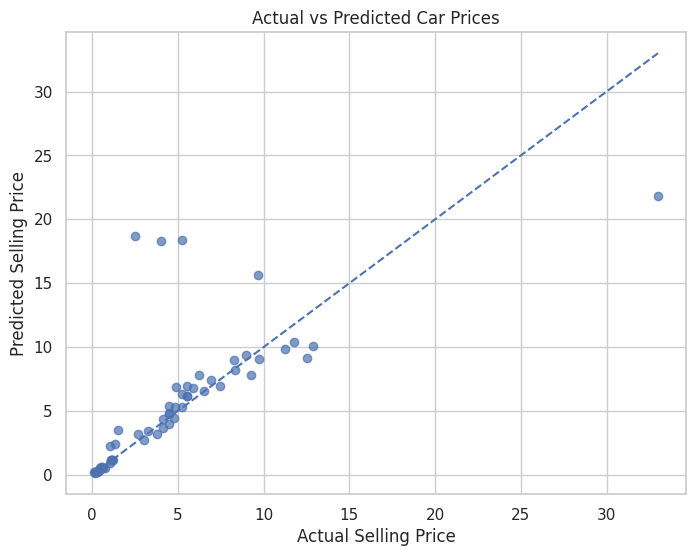

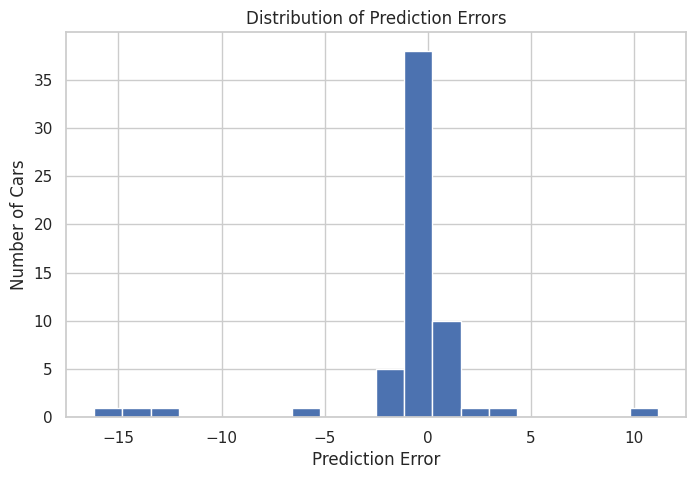


✅ Machine Learning model training completed!


In [11]:
# ==========================================
# CODEALPHA TASK 3 - MACHINE LEARNING MODEL
# CAR PRICE PREDICTION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Select Features and Target
# ------------------------------------------

features = [
    "Year",
    "Present_Price",
    "Driven_kms",
    "Fuel_Type",
    "Selling_type",
    "Transmission",
    "Owner",
    "Car_Age"
]

X = data[features]
y = data["Selling_Price"]

# ------------------------------------------
# 2. Train-Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# ------------------------------------------
# 3. Identify Categorical Columns
# ------------------------------------------

categorical_columns = [
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

numeric_columns = [
    "Year",
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age"
]

# ------------------------------------------
# 4. Preprocessing
# ------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numeric",
            "passthrough",
            numeric_columns
        )
    ]
)

# ------------------------------------------
# 5. Linear Regression
# ------------------------------------------

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

# ------------------------------------------
# 6. Random Forest Regression
# ------------------------------------------

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

# ------------------------------------------
# 7. Model Evaluation Function
# ------------------------------------------

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print("\n" + "=" * 45)
    print(name)
    print("=" * 45)

    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²  :", round(r2, 3))

    return mae, rmse, r2


# ------------------------------------------
# 8. Evaluate Both Models
# ------------------------------------------

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

rf_results = evaluate_model(
    "Random Forest Regression",
    y_test,
    rf_predictions
)

# ------------------------------------------
# 9. Compare Models
# ------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_results[0],
        rf_results[0]
    ],
    "RMSE": [
        linear_results[1],
        rf_results[1]
    ],
    "R2 Score": [
        linear_results[2],
        rf_results[2]
    ]
})

print("\nModel Comparison:")
display(results)

# ------------------------------------------
# 10. Actual vs Predicted
# ------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

# Perfect prediction line
minimum = min(y_test.min(), rf_predictions.min())
maximum = max(y_test.max(), rf_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()

# ------------------------------------------
# 11. Prediction Error Distribution
# ------------------------------------------

errors = y_test - rf_predictions

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=20)

plt.xlabel("Prediction Error")
plt.ylabel("Number of Cars")
plt.title("Distribution of Prediction Errors")

plt.show()

print("\n✅ Machine Learning model training completed!")

In [14]:
# ==========================================
# FINAL CAR PRICE PREDICTION
# ==========================================

# Select one car from the test dataset
sample_car = X_test.iloc[[0]]

# Actual price
actual_price = y_test.iloc[0]

# Predict price using Random Forest
predicted_price = random_forest_model.predict(sample_car)[0]

print("🚗 SAMPLE CAR PRICE PREDICTION")
print("=" * 40)

print("\nCar Details:")
display(sample_car)

print("Actual Selling Price  :", round(actual_price, 2), "Lakhs")
print("Predicted Selling Price:", round(predicted_price, 2), "Lakhs")

difference = abs(actual_price - predicted_price)

print("Prediction Difference  :", round(difference, 2), "Lakhs")

print("\n" + "=" * 40)
print("KEY INSIGHTS")
print("=" * 40)

print("""
1. Present price is an important factor affecting the selling price.
2. Car age can influence the resale value of a vehicle.
3. Driven kilometers can affect the selling price.
4. Fuel type, transmission and selling type also contribute to price differences.
5. Random Forest can capture non-linear relationships between car features and price.
6. Model performance was evaluated using MAE, RMSE and R² score.
""")

print("\n✅ CODEALPHA TASK 3 COMPLETED!")

🚗 SAMPLE CAR PRICE PREDICTION

Car Details:


,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
283,2016,11.8,9010,Petrol,Dealer,Manual,0,2


Actual Selling Price  : 8.99 Lakhs
Predicted Selling Price: 9.39 Lakhs
Prediction Difference  : 0.4 Lakhs

KEY INSIGHTS

1. Present price is an important factor affecting the selling price.
2. Car age can influence the resale value of a vehicle.
3. Driven kilometers can affect the selling price.
4. Fuel type, transmission and selling type also contribute to price differences.
5. Random Forest can capture non-linear relationships between car features and price.
6. Model performance was evaluated using MAE, RMSE and R² score.


✅ CODEALPHA TASK 3 COMPLETED!
